# Customer Response Analysis using NLP

In [67]:
# ===============================
# Core Python Libraries
# ===============================
import os
import pickle
import joblib
import numpy as np
import pandas as pd
from collections import Counter
from scipy.special import expit  # sigmoid

# ===============================
# Data Visualization
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ===============================
# NLP: NLTK & Gensim
# ===============================
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.util import ngrams

# ===============================
# Scikit-learn: Preprocessing, Models, Metrics
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ===============================
# TensorFlow / Keras
# ===============================
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Dense, Input, Embedding, Conv1D, GlobalMaxPooling1D, LSTM, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# ===============================
# Transformers (Hugging Face)
# ===============================
from transformers import (
    AutoTokenizer, AutoModel,
    RobertaTokenizer, RobertaModel,
    BertTokenizer, BertForSequenceClassification,
    XLNetTokenizer, XLNetForSequenceClassification
)
import torch
from torch.optim import AdamW

# ===============================
# Custom Modules
# ===============================
from metrics_calculator import MetricsCalculator
from graphs import GraphPlotter
MODEL_DIR = "model"
os.makedirs(MODEL_DIR, exist_ok=True)

In [68]:
import nltk

# Tokenizer
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Stopwords
nltk.download('stopwords', quiet=True)

# WordNet for lemmatizer
nltk.download('wordnet', quiet=True)

#  POS tagging for better lemmatization
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

True

In [69]:
def upload_dataset(file_path):
    """Load the dataset from a CSV file"""
    df = pd.read_csv(file_path,)
    return df

In [70]:
path=r"Dataset/customer_response.csv"

In [71]:
df= upload_dataset(path)
df

,Product Purchased,Ticket Type,Ticket Description,Subject,Ticket Priority,Customer Satisfaction Rating,Resolution
0,Dell XPS,Technical issue,I'm facing a problem with my {product_purchase...,Case maybe show recently my computer follow.,Low,3,Network problem
1,Microsoft Office,Billing inquiry,I'm having an issue with the {product_purchase...,Try capital clearly never color toward story.,Low,3,Account access
2,Autodesk AutoCAD,Billing inquiry,I'm having an issue with the {product_purchase...,West decision evidence bit.,Low,1,Data loss
3,Nintendo Switch,Cancellation request,I'm having an issue with the {product_purchase...,Measure tonight surface feel forward.,High,1,Data loss
4,Microsoft Xbox Controller,Product inquiry,I'm having an issue with the {product_purchase...,Measure there house management pick knowledge ...,High,1,Software bug
...,...,...,...,...,...,...,...
11098,Google Nest,Billing inquiry,I'm having an issue with the {product_purchase...,Forward house arrive upon office what.,Critical,3,Installation support
11099,Microsoft Xbox Controller,Technical issue,I'm having an issue with the {product_purchase...,Agree and day memory chance policy ok.,Medium,1,Network problem
11100,Philips Hue Lights,Technical issue,I'm having an issue with the {product_purchase...,When lose provide kitchen.,Low,1,Account access
11101,Apple AirPods,Product inquiry,I'm having an issue with the {product_purchase...,Interest particular score section.,High,1,Installation support


In [72]:
def preprocess_data(df, save_path=None, target_cols=None):

    global label_encoders
    label_encoders = {}  # dictionary to hold encoders for each target column

    if save_path and os.path.exists(save_path):
        print(f"Loading existing preprocessed file: {save_path}")
        df = pd.read_csv(save_path)
    else:
        print("Preprocessing data" + (f" and saving to: {save_path}" if save_path else " (no saving)"))
        lemmatizer = WordNetLemmatizer()
        stop_words = set(stopwords.words('english'))

        def clean_text(text):
            text = str(text).lower()
            tokens = word_tokenize(text)
            tokens = [lemmatizer.lemmatize(t) for t in tokens if t.isalnum() and t not in stop_words]
            return ' '.join(tokens)

        # Separate target columns
        target_df = None
        if target_cols:
            existing_targets = [col for col in target_cols if col in df.columns]
            target_df = df[existing_targets].copy()
            df = df.drop(columns=existing_targets)

        # Process text columns
        text_columns = df.select_dtypes(include='object').columns
        for col in text_columns:
            df[f'processed_{col}'] = df[col].apply(clean_text)

        # Drop original text columns
        df.drop(columns=text_columns, inplace=True)

        # Reattach target columns
        if target_df is not None:
            for col in target_df.columns:
                df[col] = target_df[col]

        # Save only if path is specified
        if save_path:
            df.to_csv(save_path, index=False)

    # Select processed and numerical columns
    processed_text_cols = [col for col in df.columns if col.startswith('processed_')]
    non_text_cols = [col for col in df.columns if col not in processed_text_cols + (target_cols if target_cols else [])]

    # Join processed text columns into one string
    X_text = df[processed_text_cols].astype(str).agg(' '.join, axis=1)

    # Combine with numerical columns if any
    X_numeric = df[non_text_cols].values if non_text_cols else None
    if X_numeric is not None and len(X_numeric) > 0:
        X = [f"{text} {' '.join(map(str, numeric))}" for text, numeric in zip(X_text, X_numeric)]
    else:
        X = X_text.tolist()

    # Encode multiple target columns
    Y_dict = {}
    if target_cols:
        for col in target_cols:
            if col in df.columns:
                le = LabelEncoder()
                Y_dict[col] = le.fit_transform(df[col])
                label_encoders[col] = le

    return X, Y_dict

In [73]:
X, Y_dict = preprocess_data(df, save_path="model/cleaned_data.csv", target_cols=["Ticket Priority","Customer Satisfaction Rating","Resolution"])

Preprocessing data and saving to: model/cleaned_data.csv


In [74]:
labels_vars = {}  # dictionary to hold the labels
label_encoders_original = label_encoders
for i, (col, le) in enumerate(label_encoders.items(), start=1):
    var_name = f"labels{i}"
    labels_vars[var_name] = list(le.classes_)

for idx, class_name in enumerate(labels_vars["labels1"]):
    print(f"labels{idx}: {class_name}")

labels1 = labels_vars.get("labels1")
print("labels1:", labels1)
metrics_calculator_lb1 = MetricsCalculator(labels1)

for idx, class_name in enumerate(labels_vars["labels2"]):
    print(f"labels{idx}: {class_name}")

labels2 = labels_vars.get("labels2")
print("labels2:", labels2)
metrics_calculator_lb2 = MetricsCalculator(labels2)

labels3 = labels_vars.get("labels3")
print("labels3:", labels3)
metrics_calculator_lb3 = MetricsCalculator(labels3)

labels0: Critical
labels1: High
labels2: Low
labels3: Medium
labels1: ['Critical', 'High', 'Low', 'Medium']
labels0: 1
labels1: 2
labels2: 3
labels3: 4
labels4: 5
labels2: [1, 2, 3, 4, 5]
labels3: ['Account access', 'Battery life', 'Cancellation request', 'Data loss', 'Delivery problem', 'Display issue', 'Hardware issue', 'Installation support', 'Network problem', 'Payment issue', 'Peripheral compatibility', 'Product compatibility', 'Product recommendation', 'Product setup', 'Refund request', 'Software bug']


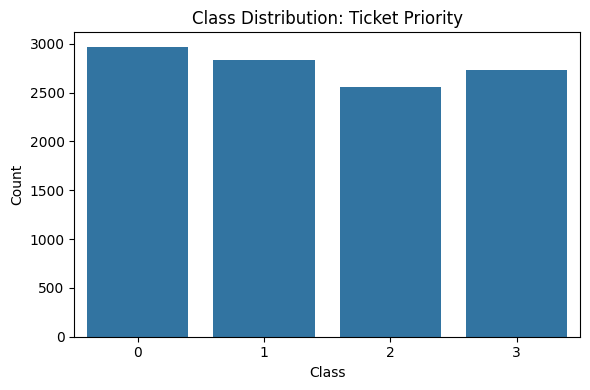

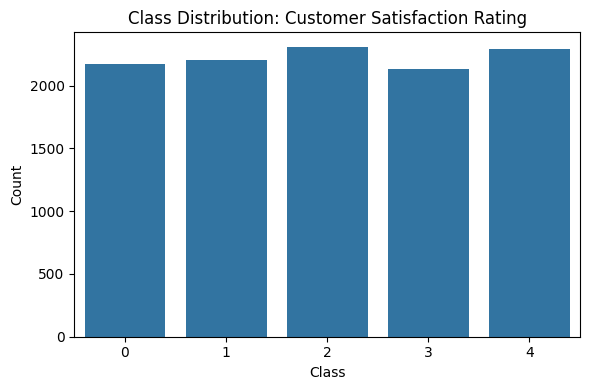

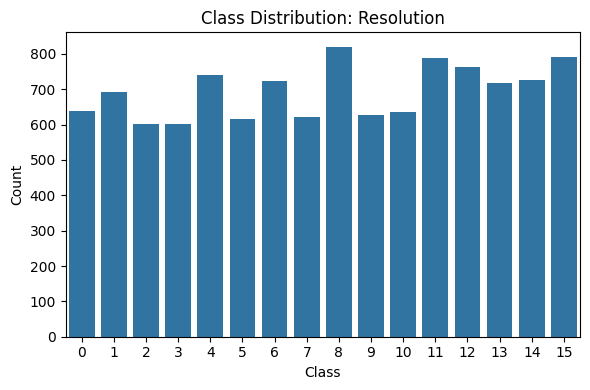

In [75]:
def plot_target_distributions(Y_dict):
    """
    Create count plots for each target column in Y_dict.
    
    Parameters:
        Y_dict (dict): Dictionary where keys are target column names and values are encoded label arrays.
    """
    # Convert to DataFrame for easy plotting
    y_df = pd.DataFrame(Y_dict)

    # Plot each column
    for col in y_df.columns:
        plt.figure(figsize=(6, 4))
        sns.countplot(x=y_df[col])
        plt.title(f'Class Distribution: {col}')
        plt.xlabel('Class')
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()
plot_target_distributions(Y_dict)


In [76]:
def eda_nlp_analysis(X_text, num_words=100, top_n_words=20):
    """
    Perform NLP EDA:
        1. WordCloud
        2. Top N words
        3. Document length histogram
        4. POS tag frequency
        5. Bigram frequency

    Parameters:
        X_text (list of str): Input preprocessed text data.
        num_words (int): Number of words to show in word cloud.
        top_n_words (int): Number of top frequent words to plot.
    """
    print("Generating NLP EDA Visualizations...")

    # Flatten all tokens from all texts
    all_tokens = [word for doc in X_text for word in word_tokenize(doc)]

    # --- 1. WordCloud ---
    word_freq = Counter(all_tokens)
    wc = WordCloud(width=800, height=400, max_words=num_words, background_color='white').generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Top {num_words} Words - WordCloud")
    plt.show()

    # --- 2. Top-N Frequent Words ---
    common_words = word_freq.most_common(top_n_words)
    words, counts = zip(*common_words)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(counts), y=list(words), palette="viridis")
    plt.title(f"Top {top_n_words} Most Frequent Words")
    plt.xlabel("Count")
    plt.ylabel("Word")
    plt.show()

    # --- 3. Document Length Histogram ---
    doc_lengths = [len(word_tokenize(doc)) for doc in X_text]
    plt.figure(figsize=(10, 5))
    sns.histplot(doc_lengths, bins=20, kde=True, color='teal')
    plt.title("Distribution of Document Lengths (in words)")
    plt.xlabel("Number of Words per Document")
    plt.ylabel("Frequency")
    plt.show()

    # --- 4. POS Tag Frequency ---
    all_pos = [tag for _, tag in pos_tag(all_tokens)]
    pos_counts = Counter(all_pos).most_common()
    pos_tags, pos_freqs = zip(*pos_counts)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(pos_tags), y=list(pos_freqs), palette="coolwarm")
    plt.title("Part of Speech (POS) Tag Frequency")
    plt.xlabel("POS Tag")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.show()

    # --- 5. Bigram Frequency Plot ---
    bigrams = list(ngrams(all_tokens, 2))
    bigram_freq = Counter(bigrams).most_common(top_n_words)
    bigram_labels = [' '.join(b) for b, _ in bigram_freq]
    bigram_counts = [count for _, count in bigram_freq]

    plt.figure(figsize=(10, 5))
    sns.barplot(x=bigram_counts, y=bigram_labels, palette="magma")
    plt.title(f"Top {top_n_words} Bigrams")
    plt.xlabel("Count")
    plt.ylabel("Bigram")
    plt.show()


Generating NLP EDA Visualizations...


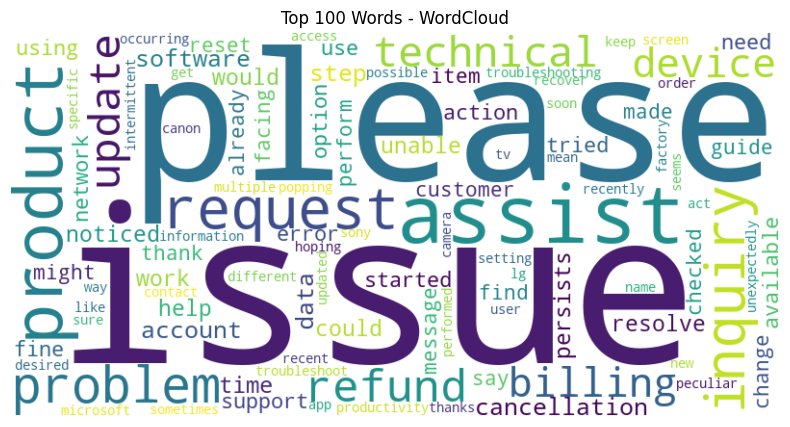

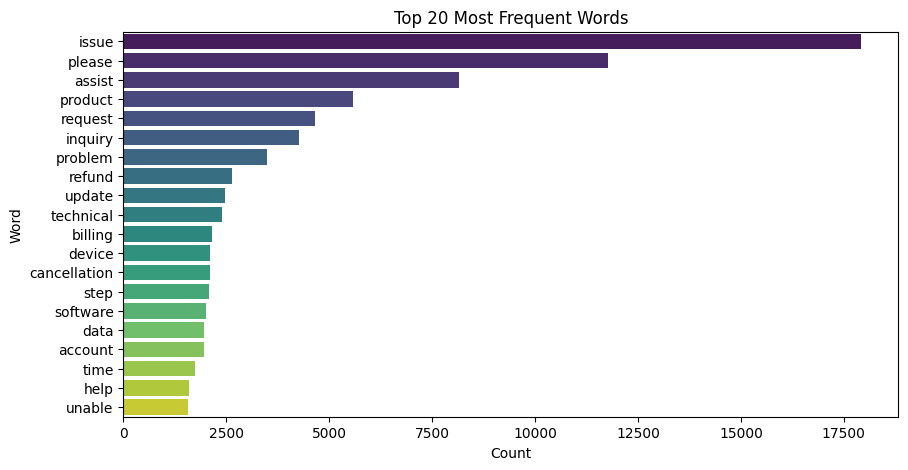

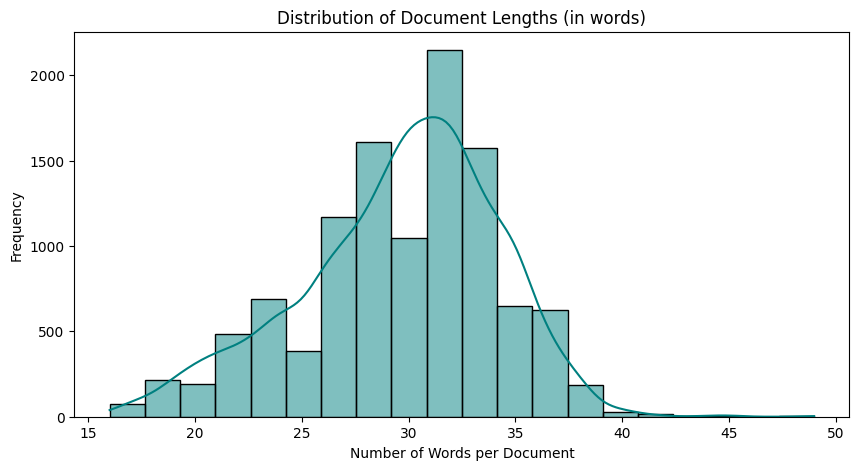

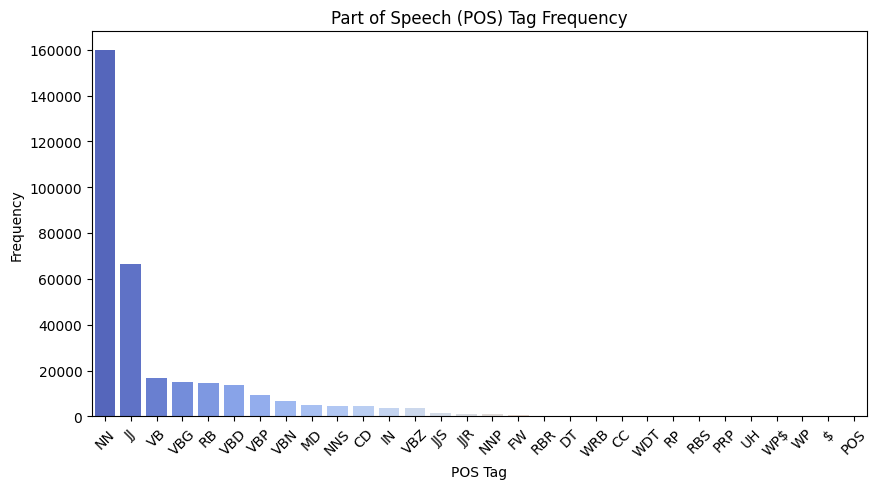

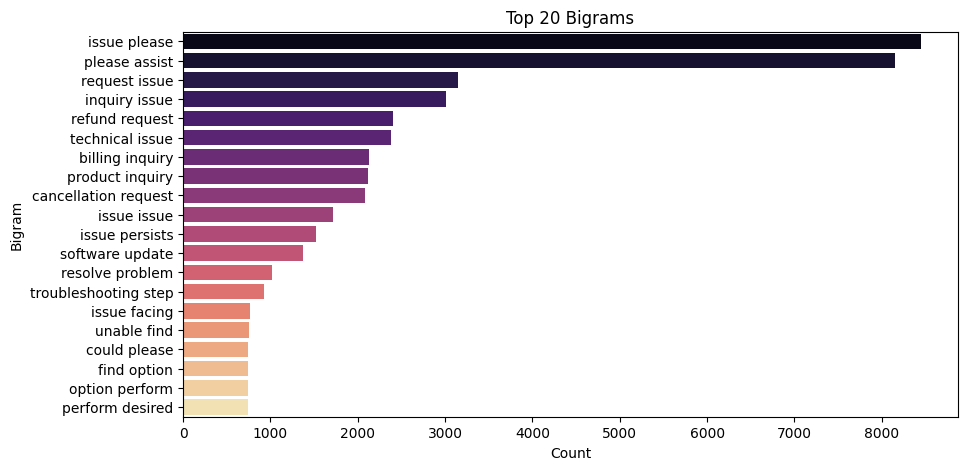

In [77]:
eda_nlp_analysis(X_text=X, num_words=100, top_n_words=20)

In [78]:
from tqdm import tqdm
import numpy as np
import os
import joblib
import torch
from transformers import XLNetTokenizer, XLNetModel

def xlnet_feature_extraction(texts, model_name='xlnet-base-cased', batch_size=32, pooling='mean'):
    tokenizer = XLNetTokenizer.from_pretrained(model_name)
    model = XLNetModel.from_pretrained(model_name)
    model.eval()

    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Extracting XLNet embeddings"):
        batch_texts = texts[i:i+batch_size]
        encoded_input = tokenizer(batch_texts, padding=True, truncation=True, return_tensors='pt')

        with torch.no_grad():
            model_output = model(**encoded_input)

        token_embeddings = model_output.last_hidden_state
        attention_mask = encoded_input['attention_mask']
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()

        if pooling == 'mean':
            sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
            sum_mask = input_mask_expanded.sum(dim=1)
            embeddings = sum_embeddings / sum_mask
        elif pooling == 'cls':
            embeddings = token_embeddings[:, -1, :]  
        else:
            raise ValueError("Pooling must be 'mean' or 'cls'")

        all_embeddings.append(embeddings.cpu().numpy())

    X = np.vstack(all_embeddings)
    return X, model


def feature_extraction(X_text, method='XLNet_Embeddings', model_dir='model', is_train=True):
    x_file = os.path.join(model_dir, f'X_{method}.pkl')

    print(f"[INFO] Feature extraction method: {method}, Train mode: {is_train}")

    if is_train:
        if os.path.exists(x_file):
            print(f"[INFO] Loading cached embeddings from {x_file}")
            X = joblib.load(x_file)
        else:
            print("[INFO] Computing embeddings...")
            X, model = xlnet_feature_extraction(X_text, pooling='mean')
            os.makedirs(model_dir, exist_ok=True)
            joblib.dump(X, x_file)
    else:
        print("[INFO] Performing embedding extraction for testing...")
        X, model = xlnet_feature_extraction(X_text, pooling='mean')

    return X

In [79]:
features = feature_extraction(X, method='XLNet_Embeddings', is_train=True)

[INFO] Feature extraction method: XLNet_Embeddings, Train mode: True
[INFO] Computing embeddings...


Extracting XLNet embeddings: 100%|████████████████████████████████████████████████████████████████| 347/347 [17:28<00:00,  3.02s/it]


In [80]:
original_features = {}
original_labels = {}

for i, (key, y) in enumerate(Y_dict.items(), start=1):
    print(f"\n🔹 Processing '{key}' (Original)...")

    original_features[f'features{i}'] = features
    original_labels[f'Y{i}'] = y

    print(f"Dataset: features{i}.shape = {features.shape}, Y{i}.shape = {y.shape}")

features_dict = {
    'Ticket Priority': original_features['features1'],
    'Customer Satisfaction Rating': original_features['features2'],
    'Resolution': original_features['features3']
}

labels_dict = {
    'Ticket Priority': original_labels['Y1'],
    'Customer Satisfaction Rating': original_labels['Y2'],
    'Resolution': original_labels['Y3']
}



🔹 Processing 'Ticket Priority' (Original)...
Dataset: features1.shape = (11103, 768), Y1.shape = (11103,)

🔹 Processing 'Customer Satisfaction Rating' (Original)...
Dataset: features2.shape = (11103, 768), Y2.shape = (11103,)

🔹 Processing 'Resolution' (Original)...
Dataset: features3.shape = (11103, 768), Y3.shape = (11103,)


In [81]:
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis, LinearDiscriminantAnalysis
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neighbors import NearestCentroid
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.linear_model import SGDClassifier

def train_ml_models(Algorithm_prefix, features_dict, Y_dict, algorithm):
    ml_models = {}

    model_mapping = {
        "QDA": QuadraticDiscriminantAnalysis,
        "LDA": LinearDiscriminantAnalysis,
        "HGB": HistGradientBoostingClassifier,
        "NC": NearestCentroid,
        "GPC": GaussianProcessClassifier,
        "SGD": SGDClassifier
    }

    if algorithm not in model_mapping:
        raise ValueError(f"Unknown algorithm: {algorithm}")

    for target_name, y_encoded in Y_dict.items():
        X = features_dict[target_name]
        model_cls = model_mapping[algorithm]

        if algorithm == "QDA":
            mdl = model_cls(reg_param=1.0, tol=1e-1)
        elif algorithm == "LDA":
            mdl = model_cls()
        elif algorithm == "HGB":
            mdl = model_cls()
        elif algorithm == "NC":
            mdl = model_cls()
        elif algorithm == "CNB":
            mdl = model_cls()
        elif algorithm == "GPC":
            mdl = model_cls()
        elif algorithm == "SGD":
            mdl = model_cls(max_iter=2000, tol=1e-3)
        else:
            mdl = model_cls()

        model_path = f"model/{Algorithm_prefix}_{target_name}_{algorithm}_model.pkl"
        algo_name = f"{Algorithm_prefix} {algorithm} [{target_name}]"

        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
        )

        if os.path.exists(model_path):
            print(f"Loading existing {algorithm} model for {target_name}...")
            mdl = joblib.load(model_path)
        else:
            print(f"Training {algorithm} for target: {target_name}...")
            mdl.fit(X_train, y_train)
            joblib.dump(mdl, model_path)

        y_pred = mdl.predict(X_test)
        try:
            y_score = mdl.predict_proba(X_test)
        except:
            y_score = None

        if target_name == "Ticket Priority":
            metrics_calculator_lb1.calculate_metrics(algo_name, y_pred, y_test, y_score)
        elif target_name == "Customer Satisfaction Rating":
            metrics_calculator_lb2.calculate_metrics(algo_name, y_pred, y_test, y_score)
        elif target_name == "Resolution":
            metrics_calculator_lb3.calculate_metrics(algo_name, y_pred, y_test, y_score)
        else:
            print(f"No metrics calculator defined for target: {target_name}")

        ml_models[f"{target_name}_{algorithm}"] = mdl

    return ml_models

Training QDA for target: Ticket Priority...
XLNet_Embeddings QDA [Ticket Priority] Accuracy  : 27.24
XLNet_Embeddings QDA [Ticket Priority] Precision : 27.58
XLNet_Embeddings QDA [Ticket Priority] Recall    : 28.27
XLNet_Embeddings QDA [Ticket Priority] FScore    : 22.59
XLNet_Embeddings QDA [Ticket Priority] Classification Report
XLNet_Embeddings QDA [Ticket Priority]
              precision    recall  f1-score   support

    Critical       0.27      0.04      0.07       594
        High       0.29      0.08      0.13       568
         Low       0.26      0.49      0.34       512
      Medium       0.28      0.52      0.37       547

    accuracy                           0.27      2221
   macro avg       0.28      0.28      0.23      2221
weighted avg       0.28      0.27      0.22      2221




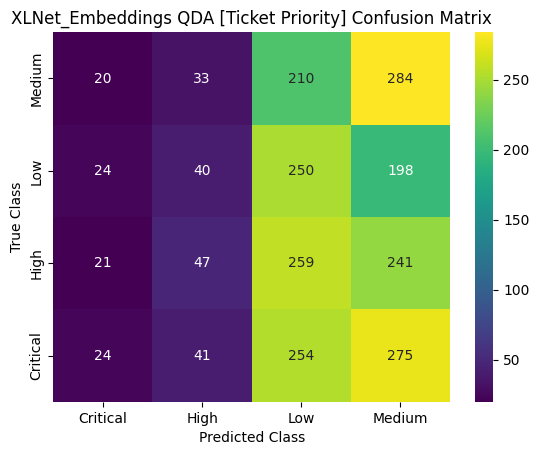

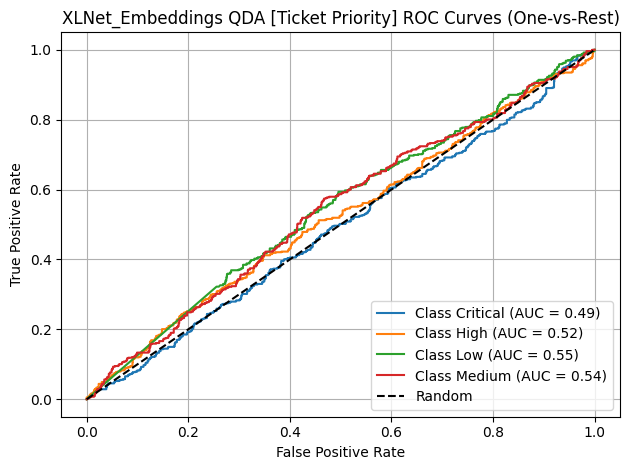

Training QDA for target: Customer Satisfaction Rating...
XLNet_Embeddings QDA [Customer Satisfaction Rating] Accuracy  : 23.41
XLNet_Embeddings QDA [Customer Satisfaction Rating] Precision : 20.69
XLNet_Embeddings QDA [Customer Satisfaction Rating] Recall    : 22.90
XLNet_Embeddings QDA [Customer Satisfaction Rating] FScore    : 19.02
XLNet_Embeddings QDA [Customer Satisfaction Rating] Classification Report
XLNet_Embeddings QDA [Customer Satisfaction Rating]
              precision    recall  f1-score   support

           1       0.21      0.20      0.20       434
           2       0.12      0.03      0.05       440
           3       0.24      0.51      0.33       462
           4       0.20      0.04      0.07       427
           5       0.26      0.37      0.31       458

    accuracy                           0.23      2221
   macro avg       0.21      0.23      0.19      2221
weighted avg       0.21      0.23      0.19      2221




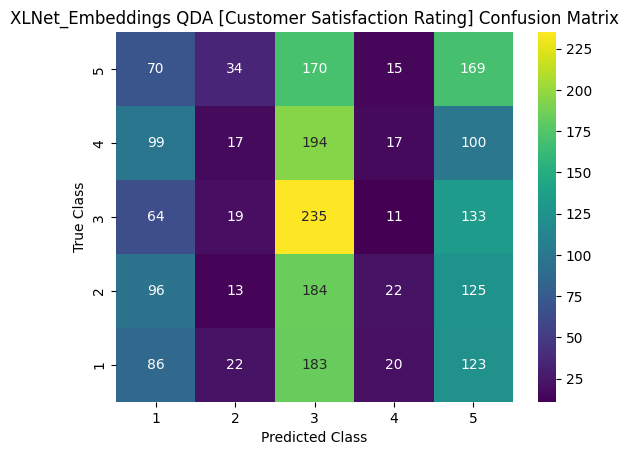

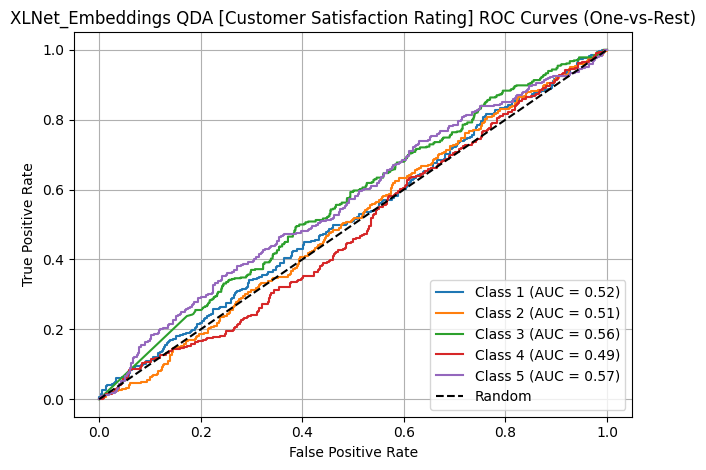

Training QDA for target: Resolution...
XLNet_Embeddings QDA [Resolution] Accuracy  : 2.84
XLNet_Embeddings QDA [Resolution] Precision : 0.63
XLNet_Embeddings QDA [Resolution] Recall    : 2.57
XLNet_Embeddings QDA [Resolution] FScore    : 1.00
XLNet_Embeddings QDA [Resolution] Classification Report
XLNet_Embeddings QDA [Resolution]
                          precision    recall  f1-score   support

          Account access       0.00      0.00      0.00       128
            Battery life       0.00      0.00      0.00       139
    Cancellation request       0.00      0.00      0.00       120
               Data loss       0.00      0.00      0.00       120
        Delivery problem       0.00      0.00      0.00       148
           Display issue       0.00      0.01      0.01       123
          Hardware issue       0.00      0.00      0.00       145
    Installation support       0.02      0.10      0.03       124
         Network problem       0.08      0.30      0.12       164
      

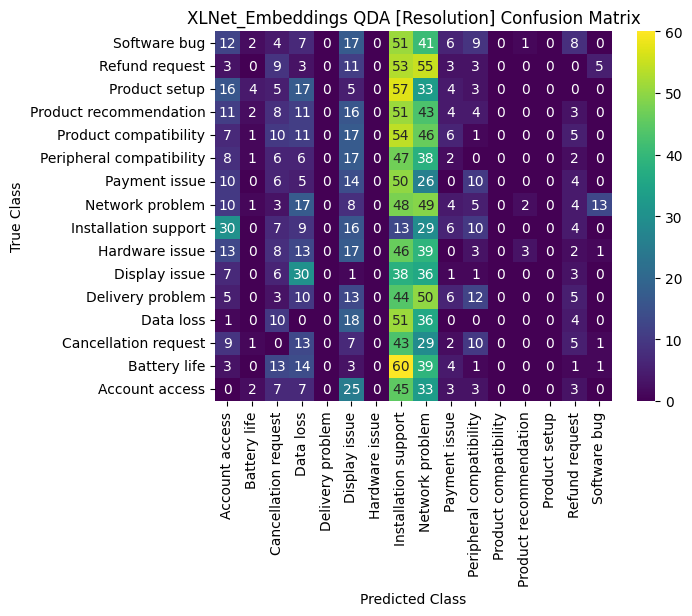

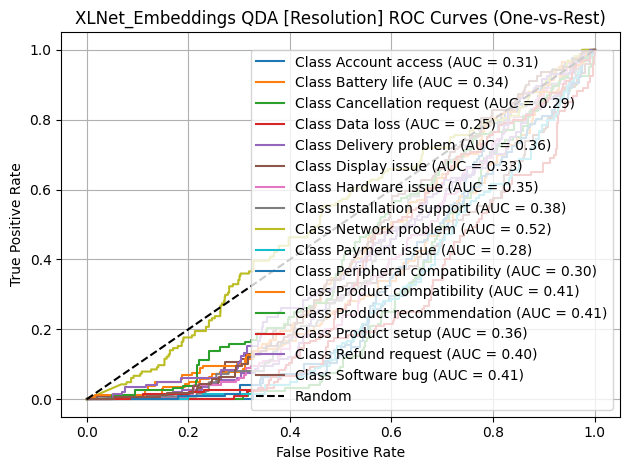

In [82]:
import warnings

# Disable all warnings
warnings.filterwarnings("ignore")

# Train the model (no warnings will be shown)
models = train_ml_models("XLNet_Embeddings", features_dict, labels_dict, "QDA")

Training LDA for target: Ticket Priority...
XLNet_Embeddings LDA [Ticket Priority] Accuracy  : 57.63
XLNet_Embeddings LDA [Ticket Priority] Precision : 57.46
XLNet_Embeddings LDA [Ticket Priority] Recall    : 57.47
XLNet_Embeddings LDA [Ticket Priority] FScore    : 57.45
XLNet_Embeddings LDA [Ticket Priority] Classification Report
XLNet_Embeddings LDA [Ticket Priority]
              precision    recall  f1-score   support

    Critical       0.60      0.61      0.61       594
        High       0.59      0.62      0.60       568
         Low       0.55      0.54      0.55       512
      Medium       0.55      0.53      0.54       547

    accuracy                           0.58      2221
   macro avg       0.57      0.57      0.57      2221
weighted avg       0.58      0.58      0.58      2221




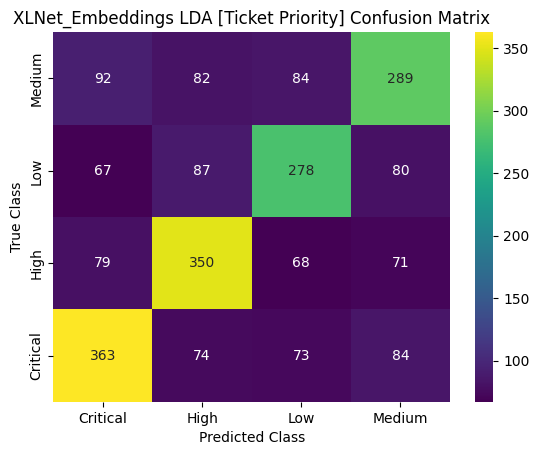

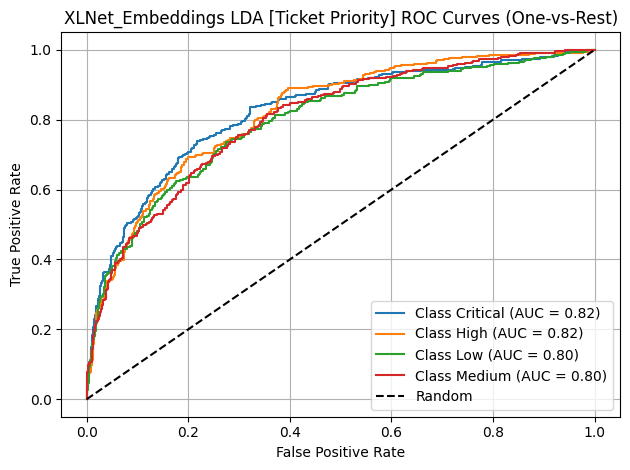

Training LDA for target: Customer Satisfaction Rating...
XLNet_Embeddings LDA [Customer Satisfaction Rating] Accuracy  : 56.01
XLNet_Embeddings LDA [Customer Satisfaction Rating] Precision : 56.03
XLNet_Embeddings LDA [Customer Satisfaction Rating] Recall    : 55.98
XLNet_Embeddings LDA [Customer Satisfaction Rating] FScore    : 56.00
XLNet_Embeddings LDA [Customer Satisfaction Rating] Classification Report
XLNet_Embeddings LDA [Customer Satisfaction Rating]
              precision    recall  f1-score   support

           1       0.54      0.55      0.55       434
           2       0.57      0.55      0.56       440
           3       0.53      0.55      0.54       462
           4       0.55      0.55      0.55       427
           5       0.61      0.60      0.61       458

    accuracy                           0.56      2221
   macro avg       0.56      0.56      0.56      2221
weighted avg       0.56      0.56      0.56      2221




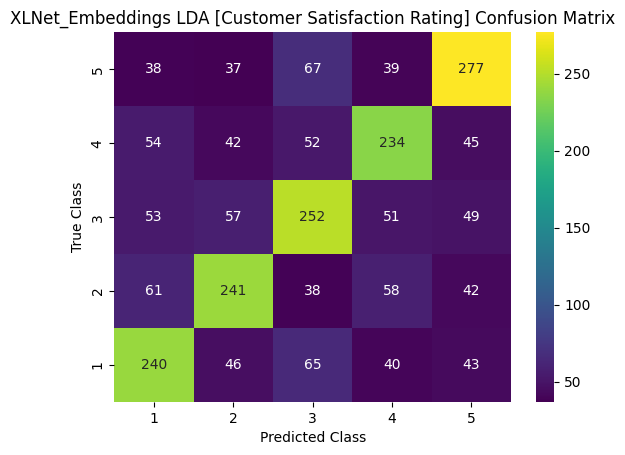

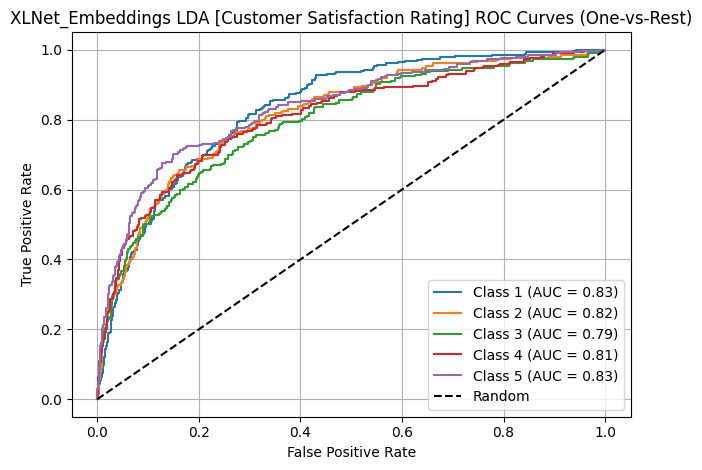

Training LDA for target: Resolution...
XLNet_Embeddings LDA [Resolution] Accuracy  : 63.17
XLNet_Embeddings LDA [Resolution] Precision : 63.50
XLNet_Embeddings LDA [Resolution] Recall    : 63.31
XLNet_Embeddings LDA [Resolution] FScore    : 63.16
XLNet_Embeddings LDA [Resolution] Classification Report
XLNet_Embeddings LDA [Resolution]
                          precision    recall  f1-score   support

          Account access       0.64      0.70      0.67       128
            Battery life       0.58      0.55      0.57       139
    Cancellation request       0.61      0.72      0.66       120
               Data loss       0.64      0.66      0.65       120
        Delivery problem       0.67      0.51      0.58       148
           Display issue       0.65      0.54      0.59       123
          Hardware issue       0.57      0.74      0.64       145
    Installation support       0.71      0.65      0.68       124
         Network problem       0.64      0.62      0.63       164
  

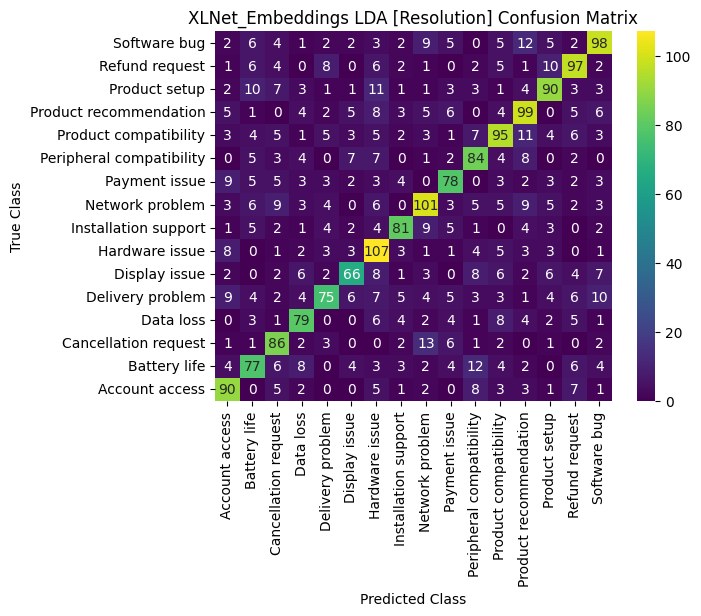

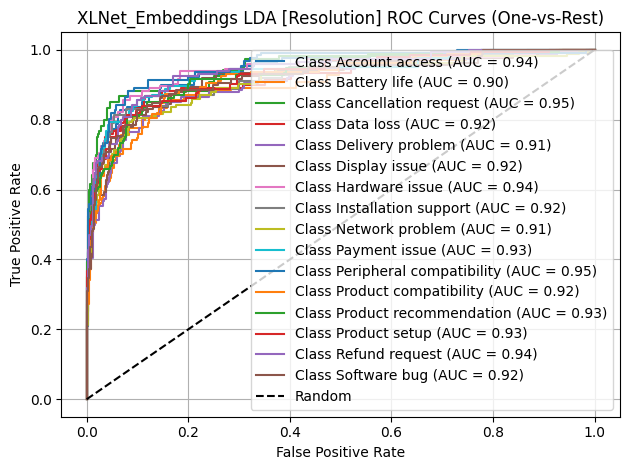

In [83]:
models = train_ml_models("XLNet_Embeddings", features_dict, labels_dict, "LDA")

Training SGD for target: Ticket Priority...
XLNet_Embeddings SGD [Ticket Priority] Accuracy  : 52.77
XLNet_Embeddings SGD [Ticket Priority] Precision : 58.10
XLNet_Embeddings SGD [Ticket Priority] Recall    : 51.92
XLNet_Embeddings SGD [Ticket Priority] FScore    : 51.02
XLNet_Embeddings SGD [Ticket Priority] Classification Report
XLNet_Embeddings SGD [Ticket Priority]
              precision    recall  f1-score   support

    Critical       0.45      0.81      0.57       594
        High       0.55      0.58      0.56       568
         Low       0.67      0.40      0.50       512
      Medium       0.66      0.29      0.40       547

    accuracy                           0.53      2221
   macro avg       0.58      0.52      0.51      2221
weighted avg       0.58      0.53      0.51      2221




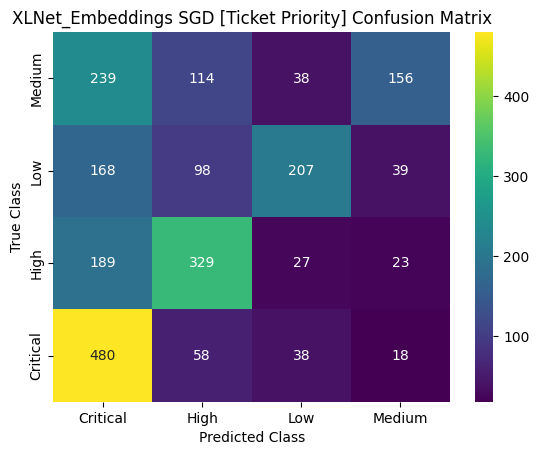

Training SGD for target: Customer Satisfaction Rating...
XLNet_Embeddings SGD [Customer Satisfaction Rating] Accuracy  : 49.75
XLNet_Embeddings SGD [Customer Satisfaction Rating] Precision : 54.93
XLNet_Embeddings SGD [Customer Satisfaction Rating] Recall    : 49.36
XLNet_Embeddings SGD [Customer Satisfaction Rating] FScore    : 48.97
XLNet_Embeddings SGD [Customer Satisfaction Rating] Classification Report
XLNet_Embeddings SGD [Customer Satisfaction Rating]
              precision    recall  f1-score   support

           1       0.53      0.35      0.42       434
           2       0.65      0.42      0.51       440
           3       0.51      0.51      0.51       462
           4       0.67      0.37      0.47       427
           5       0.40      0.82      0.53       458

    accuracy                           0.50      2221
   macro avg       0.55      0.49      0.49      2221
weighted avg       0.55      0.50      0.49      2221




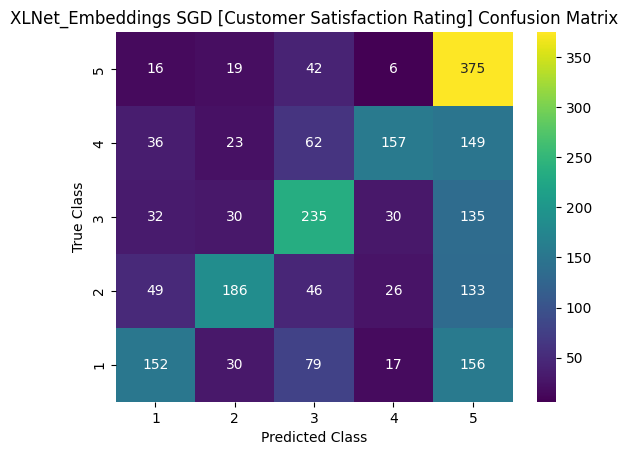

Training SGD for target: Resolution...
XLNet_Embeddings SGD [Resolution] Accuracy  : 50.47
XLNet_Embeddings SGD [Resolution] Precision : 69.22
XLNet_Embeddings SGD [Resolution] Recall    : 49.83
XLNet_Embeddings SGD [Resolution] FScore    : 44.78
XLNet_Embeddings SGD [Resolution] Classification Report
XLNet_Embeddings SGD [Resolution]
                          precision    recall  f1-score   support

          Account access       0.89      0.06      0.12       128
            Battery life       0.41      0.85      0.55       139
    Cancellation request       0.92      0.38      0.53       120
               Data loss       0.46      0.90      0.61       120
        Delivery problem       0.59      0.58      0.59       148
           Display issue       0.85      0.33      0.48       123
          Hardware issue       0.71      0.50      0.59       145
    Installation support       0.34      0.81      0.48       124
         Network problem       0.77      0.59      0.66       164
  

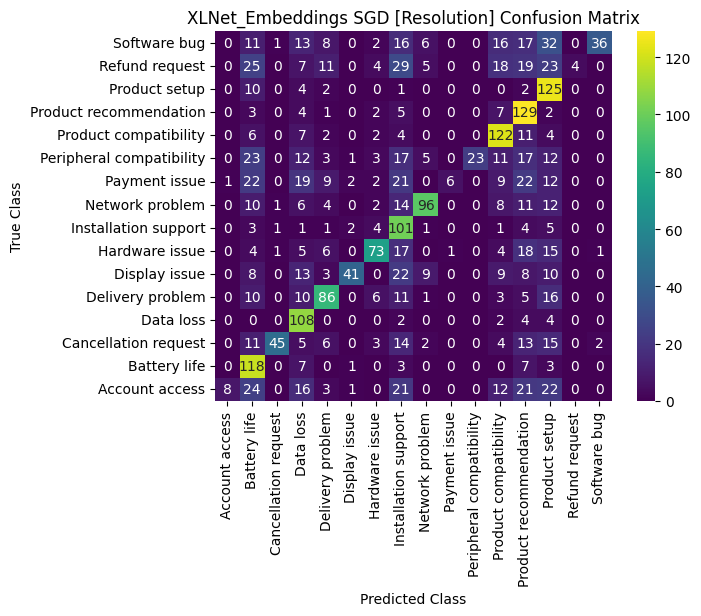

In [84]:
models = train_ml_models("XLNet_Embeddings", features_dict, labels_dict, "SGD")

Training NC for target: Ticket Priority...
XLNet_Embeddings NC [Ticket Priority] Accuracy  : 27.24
XLNet_Embeddings NC [Ticket Priority] Precision : 27.58
XLNet_Embeddings NC [Ticket Priority] Recall    : 28.27
XLNet_Embeddings NC [Ticket Priority] FScore    : 22.59
XLNet_Embeddings NC [Ticket Priority] Classification Report
XLNet_Embeddings NC [Ticket Priority]
              precision    recall  f1-score   support

    Critical       0.27      0.04      0.07       594
        High       0.29      0.08      0.13       568
         Low       0.26      0.49      0.34       512
      Medium       0.28      0.52      0.37       547

    accuracy                           0.27      2221
   macro avg       0.28      0.28      0.23      2221
weighted avg       0.28      0.27      0.22      2221




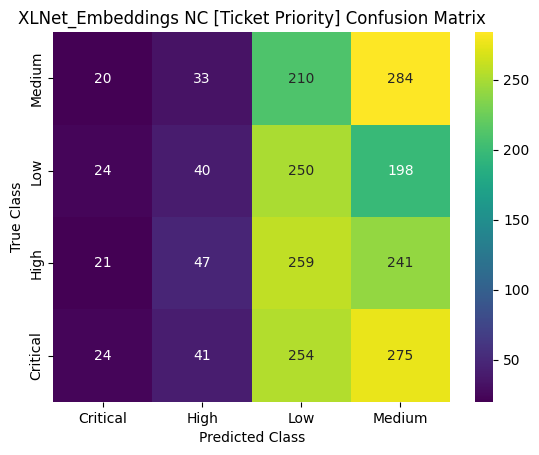

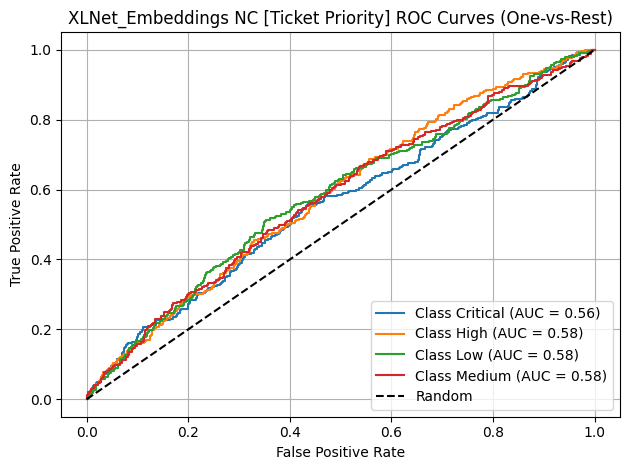

Training NC for target: Customer Satisfaction Rating...
XLNet_Embeddings NC [Customer Satisfaction Rating] Accuracy  : 23.41
XLNet_Embeddings NC [Customer Satisfaction Rating] Precision : 20.64
XLNet_Embeddings NC [Customer Satisfaction Rating] Recall    : 22.90
XLNet_Embeddings NC [Customer Satisfaction Rating] FScore    : 19.02
XLNet_Embeddings NC [Customer Satisfaction Rating] Classification Report
XLNet_Embeddings NC [Customer Satisfaction Rating]
              precision    recall  f1-score   support

           1       0.21      0.20      0.20       434
           2       0.12      0.03      0.05       440
           3       0.24      0.51      0.33       462
           4       0.20      0.04      0.07       427
           5       0.26      0.37      0.31       458

    accuracy                           0.23      2221
   macro avg       0.21      0.23      0.19      2221
weighted avg       0.21      0.23      0.19      2221




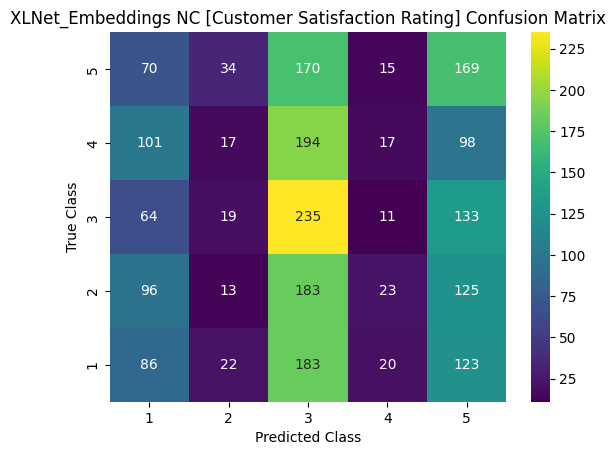

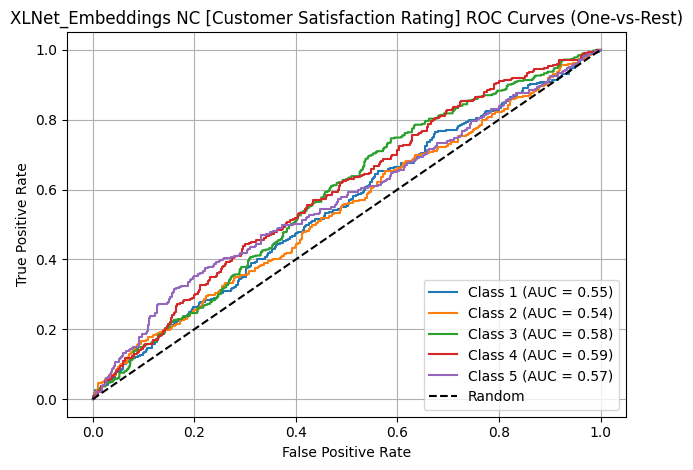

Training NC for target: Resolution...
XLNet_Embeddings NC [Resolution] Accuracy  : 7.83
XLNet_Embeddings NC [Resolution] Precision : 11.44
XLNet_Embeddings NC [Resolution] Recall    : 7.71
XLNet_Embeddings NC [Resolution] FScore    : 5.10
XLNet_Embeddings NC [Resolution] Classification Report
XLNet_Embeddings NC [Resolution]
                          precision    recall  f1-score   support

          Account access       0.13      0.11      0.12       128
            Battery life       0.18      0.06      0.09       139
    Cancellation request       0.60      0.03      0.05       120
               Data loss       0.08      0.02      0.03       120
        Delivery problem       0.20      0.01      0.01       148
           Display issue       0.09      0.13      0.10       123
          Hardware issue       0.00      0.00      0.00       145
    Installation support       0.05      0.33      0.09       124
         Network problem       0.09      0.44      0.14       164
           P

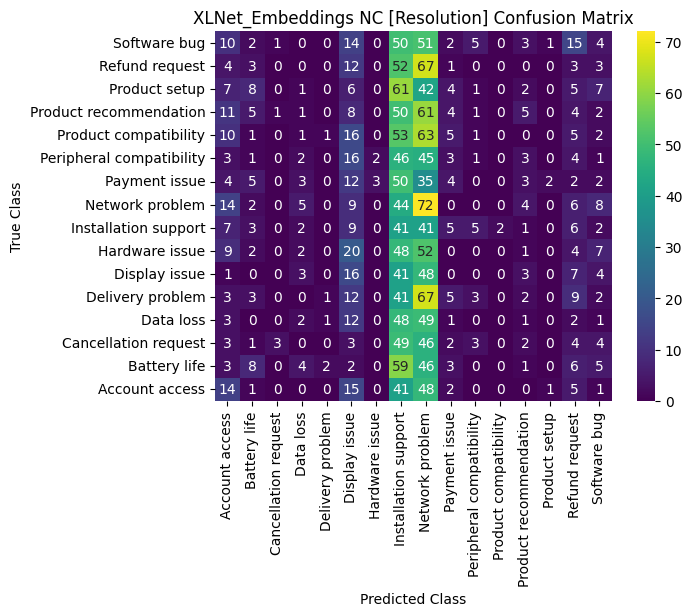

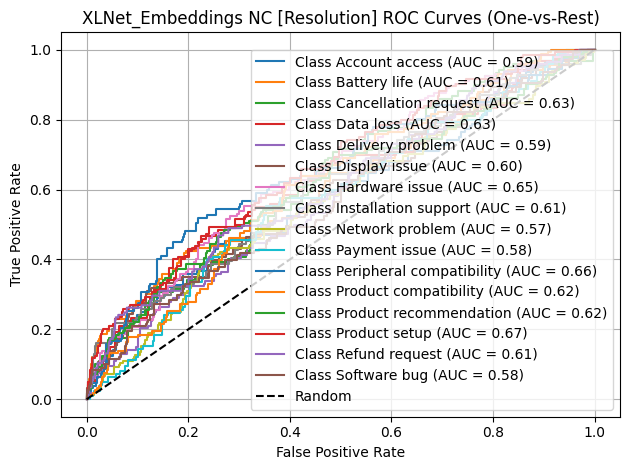

In [85]:
models = train_ml_models("XLNet_Embeddings", features_dict, labels_dict, "NC")

Training HGB for target: Ticket Priority...
XLNet_Embeddings HGB [Ticket Priority] Accuracy  : 96.17
XLNet_Embeddings HGB [Ticket Priority] Precision : 96.23
XLNet_Embeddings HGB [Ticket Priority] Recall    : 96.11
XLNet_Embeddings HGB [Ticket Priority] FScore    : 96.16
XLNet_Embeddings HGB [Ticket Priority] Classification Report
XLNet_Embeddings HGB [Ticket Priority]
              precision    recall  f1-score   support

    Critical       0.96      0.97      0.97       594
        High       0.95      0.97      0.96       568
         Low       0.98      0.94      0.96       512
      Medium       0.97      0.96      0.96       547

    accuracy                           0.96      2221
   macro avg       0.96      0.96      0.96      2221
weighted avg       0.96      0.96      0.96      2221




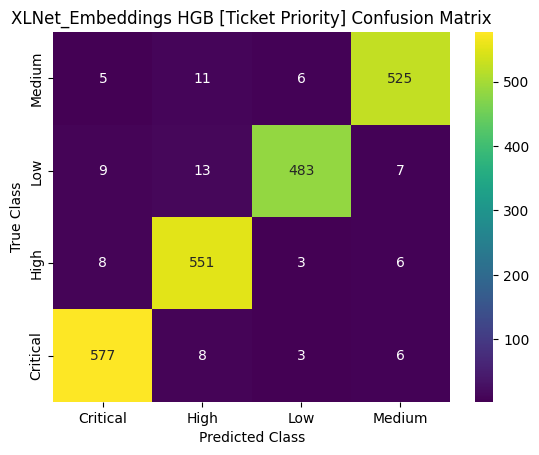

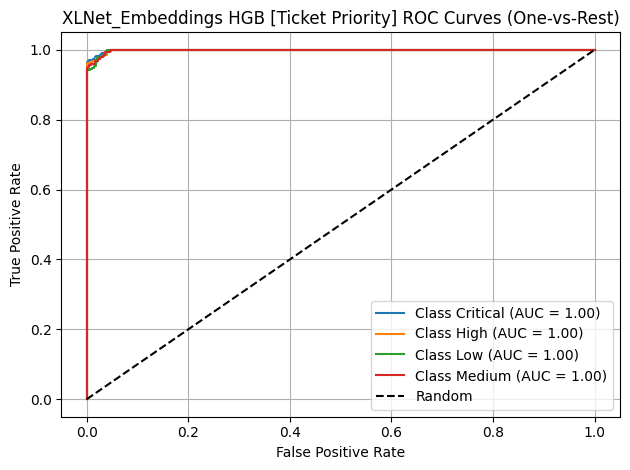

Training HGB for target: Customer Satisfaction Rating...
XLNet_Embeddings HGB [Customer Satisfaction Rating] Accuracy  : 96.26
XLNet_Embeddings HGB [Customer Satisfaction Rating] Precision : 96.28
XLNet_Embeddings HGB [Customer Satisfaction Rating] Recall    : 96.27
XLNet_Embeddings HGB [Customer Satisfaction Rating] FScore    : 96.27
XLNet_Embeddings HGB [Customer Satisfaction Rating] Classification Report
XLNet_Embeddings HGB [Customer Satisfaction Rating]
              precision    recall  f1-score   support

           1       0.95      0.97      0.96       434
           2       0.98      0.96      0.97       440
           3       0.95      0.96      0.95       462
           4       0.96      0.96      0.96       427
           5       0.97      0.97      0.97       458

    accuracy                           0.96      2221
   macro avg       0.96      0.96      0.96      2221
weighted avg       0.96      0.96      0.96      2221




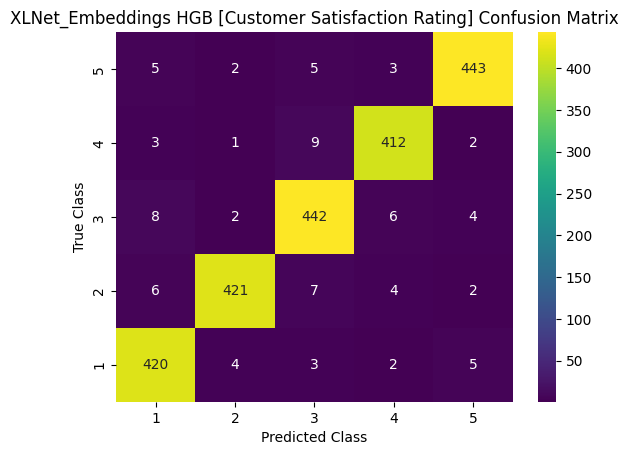

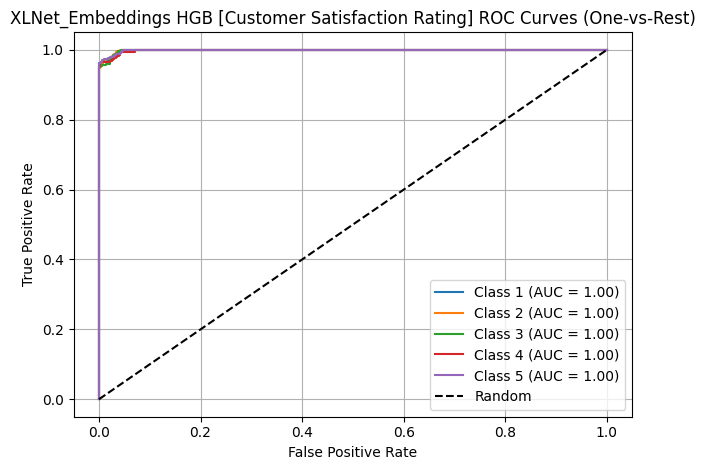

Training HGB for target: Resolution...
XLNet_Embeddings HGB [Resolution] Accuracy  : 95.41
XLNet_Embeddings HGB [Resolution] Precision : 95.60
XLNet_Embeddings HGB [Resolution] Recall    : 95.40
XLNet_Embeddings HGB [Resolution] FScore    : 95.48
XLNet_Embeddings HGB [Resolution] Classification Report
XLNet_Embeddings HGB [Resolution]
                          precision    recall  f1-score   support

          Account access       0.98      0.95      0.96       128
            Battery life       0.94      0.96      0.95       139
    Cancellation request       0.98      0.95      0.97       120
               Data loss       0.97      0.95      0.96       120
        Delivery problem       0.95      0.92      0.93       148
           Display issue       0.98      0.95      0.97       123
          Hardware issue       0.93      0.95      0.94       145
    Installation support       0.97      0.96      0.96       124
         Network problem       0.97      0.95      0.96       164
  

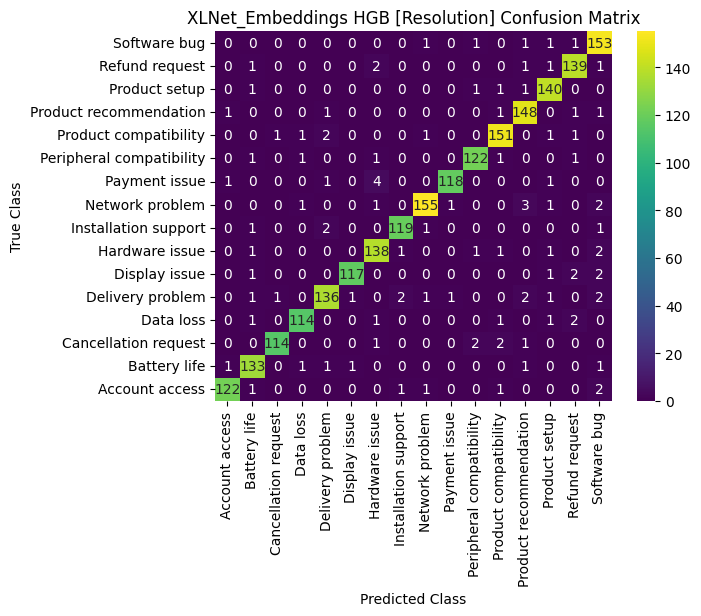

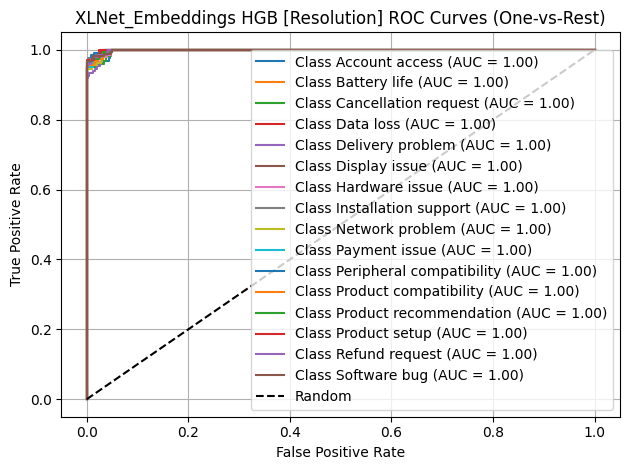

In [86]:
proposed = train_ml_models("XLNet_Embeddings", features_dict, labels_dict, "HGB")

In [87]:
melted_df_lb1 = metrics_calculator_lb1.metrics_df[['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].copy()
melted_df_lb1 = melted_df_lb1.round(3)
melted_df_lb1

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,XLNet_Embeddings QDA [Ticket Priority],27.240,27.577,28.266,22.589
1,XLNet_Embeddings LDA [Ticket Priority],57.632,57.461,57.465,57.448
2,XLNet_Embeddings SGD [Ticket Priority],52.769,58.103,51.920,51.020
3,XLNet_Embeddings NC [Ticket Priority],27.240,27.577,28.266,22.589
4,XLNet_Embeddings HGB [Ticket Priority],96.173,96.230,96.115,96.161


In [88]:
melted_df_lb2 = metrics_calculator_lb2.metrics_df[['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].copy()
melted_df_lb2 = melted_df_lb2.round(3)
melted_df_lb2

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,XLNet_Embeddings QDA [Customer Satisfaction Ra...,23.413,20.686,22.903,19.018
1,XLNet_Embeddings LDA [Customer Satisfaction Ra...,56.011,56.029,55.980,55.996
2,XLNet_Embeddings SGD [Customer Satisfaction Ra...,49.752,54.929,49.361,48.968
3,XLNet_Embeddings NC [Customer Satisfaction Rat...,23.413,20.641,22.903,19.021
4,XLNet_Embeddings HGB [Customer Satisfaction Ra...,96.263,96.283,96.268,96.271


In [33]:
melted_df_lb3 = metrics_calculator_lb2.metrics_df[['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].copy()
melted_df_lb3 = melted_df_lb2.round(3)
melted_df_lb3

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,XLNet_Embeddings QDA [Customer Satisfaction Ra...,23.098,28.033,23.066,19.485
1,XLNet_Embeddings LDA [Customer Satisfaction Ra...,57.722,57.769,57.737,57.743
2,XLNet_Embeddings LDA [Customer Satisfaction Ra...,57.722,57.769,57.737,57.743
3,XLNet_Embeddings SGD [Customer Satisfaction Ra...,38.856,54.368,39.239,32.647
4,XLNet_Embeddings NC [Customer Satisfaction Rat...,23.098,28.036,23.066,19.486
5,XLNet_Embeddings HGB [Customer Satisfaction Ra...,96.623,96.625,96.627,96.623


In [89]:
test_path=r"Dataset/Test_less.csv"

In [90]:
df_test1= upload_dataset(test_path)
df_test1
# Initialize result DataFrame
df_result = df_test1.copy()


In [91]:
df_test,_ = preprocess_data(df_test1)

Preprocessing data (no saving)


In [92]:
features_test = feature_extraction(df_test, method='XLNet_Embeddings', is_train=None)

[INFO] Feature extraction method: XLNet_Embeddings, Train mode: None
[INFO] Performing embedding extraction for testing...


Extracting XLNet embeddings: 100%|████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.63s/it]


In [93]:
model_path = r"model\XLNet_Embeddings_Ticket Priority_HGB_model.pkl"
model = joblib.load(model_path)
y_pred = model.predict(features_test)
mapped_labels = [labels1[i] for i in y_pred]
df_result[f'Predicted_Ticket_Priority'] = mapped_labels

In [94]:
model_path = r"model\XLNet_Embeddings_Customer Satisfaction Rating_HGB_model.pkl"
model = joblib.load(model_path)
y_pred = model.predict(features_test)
mapped_labels = [labels2[i] for i in y_pred]
df_result[f'Predicted_Customer Satisfaction Rating'] = mapped_labels

In [95]:
model_path = r"model\XLNet_Embeddings_Resolution_HGB_model.pkl"
model = joblib.load(model_path)
y_pred = model.predict(features_test)
mapped_labels = [labels3[i] for i in y_pred]
df_result[f'Predicted_Resolution'] = mapped_labels

In [96]:
df_result

,Product Purchased,Ticket Type,Ticket Description,Subject,Predicted_Ticket_Priority,Predicted_Customer Satisfaction Rating,Predicted_Resolution
0,Dell XPS,Technical issue,I'm facing a problem with my {product_purchase...,Case maybe show recently my computer follow.,Low,3,Network problem
1,Microsoft Office,Billing inquiry,I'm having an issue with the {product_purchase...,Try capital clearly never color toward story.,Low,3,Account access
2,Autodesk AutoCAD,Billing inquiry,I'm having an issue with the {product_purchase...,West decision evidence bit.,Low,1,Data loss
3,Nintendo Switch,Cancellation request,I'm having an issue with the {product_purchase...,Measure tonight surface feel forward.,High,1,Data loss
4,Microsoft Xbox Controller,Product inquiry,I'm having an issue with the {product_purchase...,Measure there house management pick knowledge ...,High,1,Software bug
5,Sony PlayStation,Billing inquiry,I'm having an issue with the {product_purchase...,Officer moment world sing parent available.,High,4,Product setup
6,Xbox,Product inquiry,I'm having an issue with the {product_purchase...,Seek evidence book collection catch.,Critical,4,Account access
7,Canon EOS,Refund request,I'm having an issue with the {product_purchase...,Wish mouth build resource though.,Low,5,Software bug
8,Fitbit Charge,Technical issue,I'm having an issue with the {product_purchase...,Soldier we such inside.,Critical,5,Product recommendation
9,Xbox,Cancellation request,I'm having an issue with the {product_purchase...,Firm sort voice above which site arrive.,Medium,1,Cancellation request
